# Make Number_of_plots.jpg
Reads pre-exported data from `../figure_data/figure_S_number_of_plots/` and produces the figure.

In [1]:
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from conus_biomass import dir_info

DATA_DIR = "../figure_data/figure_S_number_of_plots/"

## Load data

In [2]:
# Reprojected binned plot counts
counts_modeled_reproj = xr.open_dataset(DATA_DIR + "counts_modeled_reproj.nc")["n_plots"]

# FIA plot lon/lat for scatter overlay
fia_lonlat = pd.read_csv(DATA_DIR + "fia_plot_locations.csv")

# Target CRS (used when reprojecting the shapefile)
with open(DATA_DIR + "target_crs.txt") as f:
    target_crs = f.read()

# Western-states shapefile (already reprojected to target_crs)
shp_native = gpd.read_file(DATA_DIR + "shp_western_native.gpkg")

## Make figure

In [3]:
def setup_ax(ax):
    ax.set_axis_off()
    shp_native.boundary.plot(ax=ax, color="gray", linewidth=1)

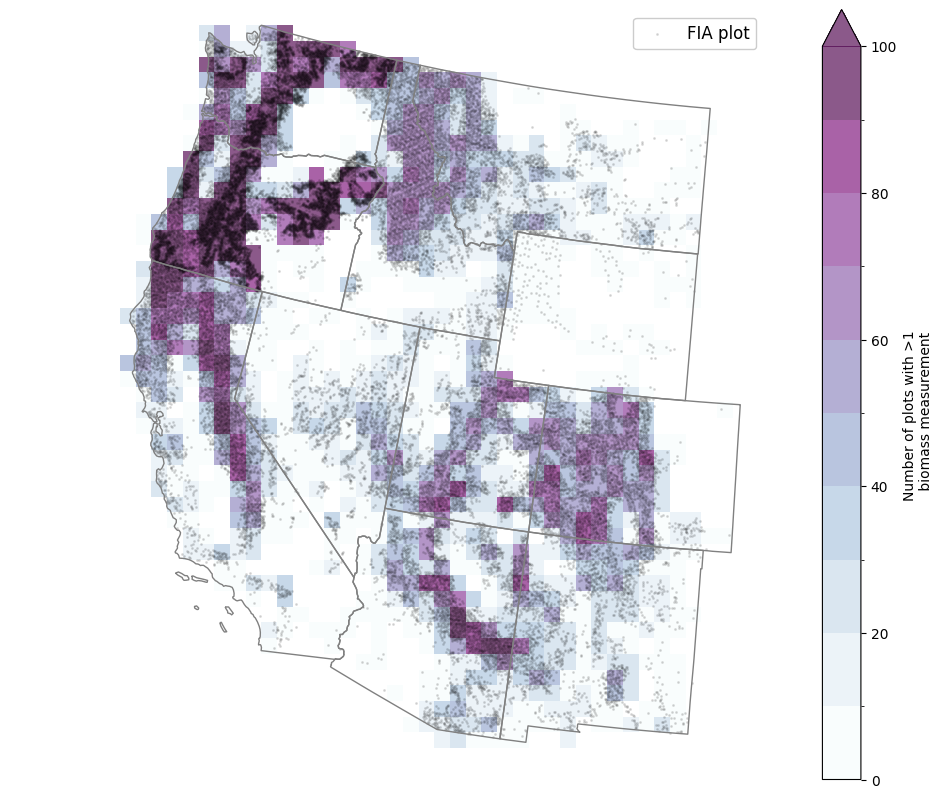

In [4]:
proj_crs = ccrs.AlbersEqualArea(
    central_longitude=-96, central_latitude=23, standard_parallels=(29.5, 45.5)
)

fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={"projection": proj_crs})

cmap = plt.cm.BuPu
bounds = np.arange(0, 110, 10)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

im = counts_modeled_reproj.plot(ax=ax, norm=norm, cmap=cmap, add_colorbar=False, alpha=0.65)
ax.set_title("")
setup_ax(ax)

ax.scatter(
    fia_lonlat["lon"],
    fia_lonlat["lat"],
    color="black",
    s=1.4,
    alpha=0.1,
    transform=ccrs.PlateCarree(),
    label="FIA plot",
)
plt.legend(framealpha=1, fontsize=12)

cbar = fig.colorbar(im, ax=ax, orientation="vertical", extend="max")
cbar.set_label("Number of plots with >1 \n biomass measurement")

plt.savefig(dir_info.dir_figures + "Number_of_plots.jpg", dpi=300)
plt.show()